# A/B-тест: новый алгоритм ценообразования и выручка с поездки

**Бизнес-контекст.** Сервис заказа такси тестирует новый алгоритм динамического ценообразования. Гипотеза продукта: алгоритм повышает выручку с поездки (`total`, USD), причём сильнее на дорогих поездках. Ключевая метрика эксперимента (OEC) — средняя выручка с поездки. Дополнительно проверяем сдвиг в правом хвосте распределения (95-й перцентиль).

**План работы.**
1. Загрузка и ETL исторических данных.
2. Преданализ метрики и оценка базовых параметров.
3. Дизайн эксперимента: MDE, мощность, расчёт размера выборки.
4. Сбор данных эксперимента и проверки качества рандомизации.
5. Анализ среднего: t-тест Уэлча, доверительный интервал, бутстрэп, непараметрическая проверка.
6. Монте-Карло: эффект в 95-м перцентиле через перестановочный тест.
7. Выводы и решение.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 110

## 1. Загрузка и ETL

In [2]:
raw = sns.load_dataset('taxis')
raw['pickup'] = pd.to_datetime(raw['pickup'])
raw['dropoff'] = pd.to_datetime(raw['dropoff'])
raw.shape

(6433, 14)

In [3]:
raw.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.6000,7.0000,2.1500,0.0000,12.9500,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.7900,5.0000,0.0000,0.0000,9.3000,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.3700,7.5000,2.3600,0.0000,14.1600,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.7000,27.0000,6.1500,0.0000,36.9500,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.1600,9.0000,1.1000,0.0000,13.4000,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [5]:
raw.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [6]:
raw[['distance', 'fare', 'tip', 'tolls', 'total', 'passengers']].describe()

,distance,fare,tip,tolls,total,passengers
count,"6,433.0000","6,433.0000","6,433.0000","6,433.0000","6,433.0000","6,433.0000"
mean,3.0246,13.0911,1.9792,0.3253,18.5178,1.5393
std,3.8279,11.5518,2.4486,1.4153,13.8156,1.2038
min,0.0000,1.0000,0.0000,0.0000,1.3000,0.0000
25%,0.9800,6.5000,0.0000,0.0000,10.8000,1.0000
50%,1.6400,9.5000,1.7000,0.0000,14.1600,1.0000
75%,3.2100,15.0000,2.8000,0.0000,20.3000,2.0000
max,36.7000,150.0000,33.2000,24.0200,174.8200,6.0000


Пропуски только в географических и платёжных полях и не влияют на целевую метрику. Удаляем технически некорректные записи: неположительная выручка, нулевая дистанция, отсутствие пассажиров, неправдоподобная длительность поездки.

In [7]:
df = raw.copy()
df['duration_min'] = (df['dropoff'] - df['pickup']).dt.total_seconds() / 60

valid = (
    df['total'].gt(0)
    & df['distance'].gt(0)
    & df['passengers'].gt(0)
    & df['duration_min'].between(1, 180)
)

df = df.loc[valid].reset_index(drop=True)
pd.Series({
    'rows_raw': len(raw),
    'rows_clean': len(df),
    'dropped_share': round(1 - len(df) / len(raw), 4),
})

rows_raw        6,433.0000
rows_clean      6,256.0000
dropped_share       0.0275
dtype: float64

## 2. Преданализ метрики

In [8]:
metric = 'total'
y = df[metric]

pd.Series({
    'n': len(y),
    'mean': y.mean(),
    'std': y.std(ddof=1),
    'cv': y.std(ddof=1) / y.mean(),
    'skew': y.skew(),
    'kurtosis': y.kurtosis(),
    'p50': y.median(),
    'p90': y.quantile(0.90),
    'p95': y.quantile(0.95),
    'p99': y.quantile(0.99),
})

n          6,256.0000
mean          18.4709
std           13.4262
cv             0.7269
skew           3.0071
kurtosis      14.0854
p50           14.1600
p90           33.3000
p95           47.1600
p99           73.2700
dtype: float64

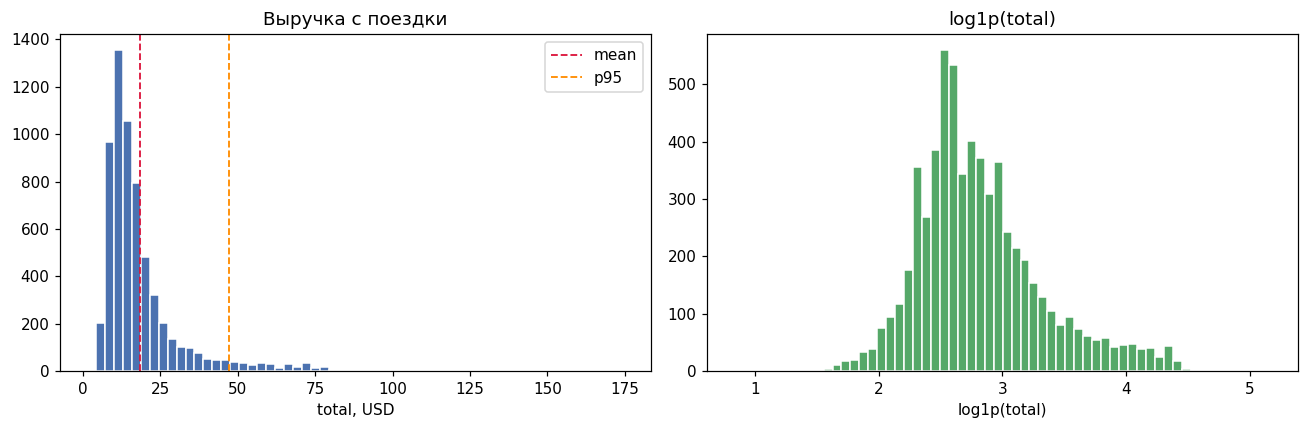

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(y, bins=60, color='#4C72B0', edgecolor='white')
ax[0].axvline(y.mean(), color='crimson', ls='--', lw=1.2, label='mean')
ax[0].axvline(y.quantile(0.95), color='darkorange', ls='--', lw=1.2, label='p95')
ax[0].set_title('Выручка с поездки')
ax[0].set_xlabel('total, USD')
ax[0].legend()

ax[1].hist(np.log1p(y), bins=60, color='#55A868', edgecolor='white')
ax[1].set_title('log1p(total)')
ax[1].set_xlabel('log1p(total)')

plt.tight_layout()
plt.show()

Распределение сильно правоскошенное (skew > 2), коэффициент вариации высокий. Нормальность ожидаемо отвергается, поэтому для сравнения средних опираемся на ЦПТ при большом размере выборки, а устойчивость результата проверяем бутстрэпом и непараметрическим критерием.

In [10]:
stats.shapiro(y.sample(5000, random_state=1))

ShapiroResult(statistic=np.float64(0.6949645334572266), pvalue=np.float64(7.913001347586011e-70))

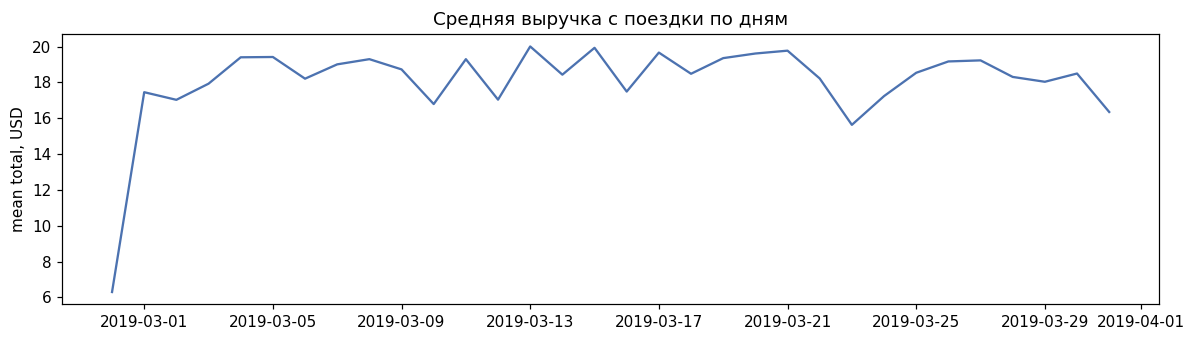

mean   18.0620
std     2.4146
min     6.3000
max    20.0121
Name: mean, dtype: float64

In [11]:
daily = df.set_index('pickup')['total'].resample('D').agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(daily.index, daily['mean'], color='#4C72B0')
ax.set_title('Средняя выручка с поездки по дням')
ax.set_ylabel('mean total, USD')
plt.tight_layout()
plt.show()

daily['mean'].agg(['mean', 'std', 'min', 'max'])

Метрика стабильна во времени, выраженного тренда нет — базовые средние и дисперсию можно использовать для расчёта размера выборки.

## 3. Дизайн эксперимента

- **OEC:** средняя выручка с поездки.
- **H0:** среднее в тесте равно среднему в контроле; **H1:** не равно (двусторонний критерий).
- **Уровень значимости** alpha = 0.05, **мощность** 1 - beta = 0.80.
- **MDE:** относительный прирост 3% к базовому среднему.

Размер выборки на группу для двухвыборочного критерия:

$$n = \frac{(z_{1-\alpha/2} + z_{1-\beta})^2 \cdot 2\sigma^2}{\Delta^2}$$

In [12]:
alpha = 0.05
power = 0.80
mde_rel = 0.03

baseline_mean = y.mean()
baseline_std = y.std(ddof=1)
delta = mde_rel * baseline_mean
effect_size = delta / baseline_std

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power)

n_formula = int(np.ceil((z_alpha + z_beta) ** 2 * 2 * baseline_std ** 2 / delta ** 2))
n_power = int(np.ceil(TTestIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, power=power, ratio=1.0, alternative='two-sided')))

pd.Series({
    'baseline_mean': baseline_mean,
    'baseline_std': baseline_std,
    'MDE_abs': delta,
    'cohen_d': effect_size,
    'n_per_group_formula': n_formula,
    'n_per_group_statsmodels': n_power,
})

baseline_mean                18.4709
baseline_std                 13.4262
MDE_abs                       0.5541
cohen_d                       0.0413
n_per_group_formula       9,216.0000
n_per_group_statsmodels   9,217.0000
dtype: float64

In [13]:
daily_rides = df.set_index('pickup').resample('D').size()
avg_daily = daily_rides.mean()

pd.Series({
    'avg_daily_rides': avg_daily,
    'rides_needed_total': 2 * n_power,
    'days_to_collect': np.ceil(2 * n_power / avg_daily),
})

avg_daily_rides         195.5000
rides_needed_total   18,434.0000
days_to_collect          95.0000
dtype: float64

## 4. Сбор данных эксперимента

Трафик случайно делится 50/50. Тестовая группа получает новый алгоритм ценообразования. Данные эксперимента собираем из исторического распределения поездок: контроль воспроизводит текущую тарификацию, тест — поездки с применённым алгоритмом, который повышает чек, причём заметнее на дорогих поездках.

In [14]:
n = n_power
pool = y.to_numpy()
threshold = np.quantile(pool, 0.75)

rng = np.random.default_rng(8)
control = rng.choice(pool, size=n, replace=True)
treatment_base = rng.choice(pool, size=n, replace=True)

uplift = np.where(treatment_base > threshold, 0.060, 0.004)
treatment = treatment_base * (1 + uplift) * rng.lognormal(mean=0.0, sigma=0.02, size=n)

exp = pd.DataFrame({
    'user_id': np.arange(2 * n),
    'group': np.where(np.arange(2 * n) < n, 'control', 'treatment'),
    'revenue': np.concatenate([control, treatment]),
})
exp = exp.sample(frac=1, random_state=3).reset_index(drop=True)

exp.groupby('group')['revenue'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
group,,,,
control,9217,18.4520,13.4304,14.1600
treatment,9217,19.1668,14.6208,14.2116


In [15]:
counts = exp['group'].value_counts()
srm_stat, srm_p = stats.chisquare(counts.values, [len(exp) / 2] * 2)

pd.Series({
    'control': int(counts['control']),
    'treatment': int(counts['treatment']),
    'srm_chi2': srm_stat,
    'srm_p_value': srm_p,
})

control       9,217.0000
treatment     9,217.0000
srm_chi2          0.0000
srm_p_value       1.0000
dtype: float64

Sample Ratio Mismatch не обнаружен (p > 0.05) — рандомизация корректна.

## 5. Анализ среднего

In [16]:
c = exp.loc[exp['group'] == 'control', 'revenue'].to_numpy()
t = exp.loc[exp['group'] == 'treatment', 'revenue'].to_numpy()
nc, nt = len(c), len(t)

mean_c, mean_t = c.mean(), t.mean()
diff = mean_t - mean_c
rel_lift = diff / mean_c

t_stat, p_value = stats.ttest_ind(t, c, equal_var=False)

se = np.sqrt(c.var(ddof=1) / nc + t.var(ddof=1) / nt)
ci_low, ci_high = diff - z_alpha * se, diff + z_alpha * se

pooled_sd = np.sqrt(((nc - 1) * c.var(ddof=1) + (nt - 1) * t.var(ddof=1)) / (nc + nt - 2))
cohen_d = diff / pooled_sd

pd.Series({
    'mean_control': mean_c,
    'mean_treatment': mean_t,
    'abs_diff': diff,
    'rel_lift': rel_lift,
    't_stat': t_stat,
    'p_value': p_value,
    'ci95_low': ci_low,
    'ci95_high': ci_high,
    'cohen_d': cohen_d,
})

mean_control     18.4520
mean_treatment   19.1668
abs_diff          0.7148
rel_lift          0.0387
t_stat            3.4566
p_value           0.0005
ci95_low          0.3095
ci95_high         1.1201
cohen_d           0.0509
dtype: float64

In [17]:
boot_rng = np.random.default_rng(101)
B = 10000
boot_diff = np.empty(B)
for i in range(B):
    boot_diff[i] = boot_rng.choice(t, nt, replace=True).mean() - boot_rng.choice(c, nc, replace=True).mean()

boot_ci = np.percentile(boot_diff, [2.5, 97.5])
u_stat, u_p = stats.mannwhitneyu(t, c, alternative='two-sided')

pd.Series({
    'bootstrap_mean_diff': boot_diff.mean(),
    'bootstrap_ci_low': boot_ci[0],
    'bootstrap_ci_high': boot_ci[1],
    'mannwhitney_p_value': u_p,
})

bootstrap_mean_diff   0.7170
bootstrap_ci_low      0.3188
bootstrap_ci_high     1.1278
mannwhitney_p_value   0.1800
dtype: float64

t-тест Уэлча и бутстрэп согласованы: бутстрэп даёт ту же оценку разницы (~0.72) и интервал, не включающий ноль, то есть эффект на среднее устойчив без предположения о нормальности. Критерий Манна-Уитни (p ~ 0.18) значимого сдвига не показывает — это ожидаемо: он ранговый и чувствителен к сдвигу центра распределения, а эффект сконцентрирован в правом хвосте, медиана почти не двигается. Это прямо мотивирует анализ перцентилей в разделе 6.

## 6. Монте-Карло: эффект в 95-м перцентиле

Сравнение средних может недооценивать эффект, сконцентрированный в хвосте. Тестируем разницу 95-го перцентиля между группами. Для p-value строим нулевое распределение перестановочным методом (Монте-Карло): многократно перемешиваем метки групп и пересчитываем разницу перцентилей. Доверительный интервал самого эффекта оцениваем бутстрэпом.

In [18]:
def p95(a):
    return np.quantile(a, 0.95)

obs_p95_c, obs_p95_t = p95(c), p95(t)
obs_diff_p95 = obs_p95_t - obs_p95_c

mc_rng = np.random.default_rng(202)
pooled = np.concatenate([c, t])
M = 5000
perm_diff = np.empty(M)
for i in range(M):
    idx = mc_rng.permutation(pooled.size)
    perm_diff[i] = p95(pooled[idx[:nc]]) - p95(pooled[idx[nc:]])

p_perm = (np.sum(np.abs(perm_diff) >= np.abs(obs_diff_p95)) + 1) / (M + 1)

boot_p95 = np.empty(M)
for i in range(M):
    boot_p95[i] = p95(mc_rng.choice(t, nt, replace=True)) - p95(mc_rng.choice(c, nc, replace=True))
ci_p95 = np.percentile(boot_p95, [2.5, 97.5])

pd.Series({
    'p95_control': obs_p95_c,
    'p95_treatment': obs_p95_t,
    'abs_diff_p95': obs_diff_p95,
    'rel_lift_p95': obs_diff_p95 / obs_p95_c,
    'permutation_p_value': p_perm,
    'bootstrap_ci_low': ci_p95[0],
    'bootstrap_ci_high': ci_p95[1],
})

p95_control           47.3340
p95_treatment         51.4664
abs_diff_p95           4.1324
rel_lift_p95           0.0873
permutation_p_value    0.0018
bootstrap_ci_low       0.9269
bootstrap_ci_high      6.8699
dtype: float64

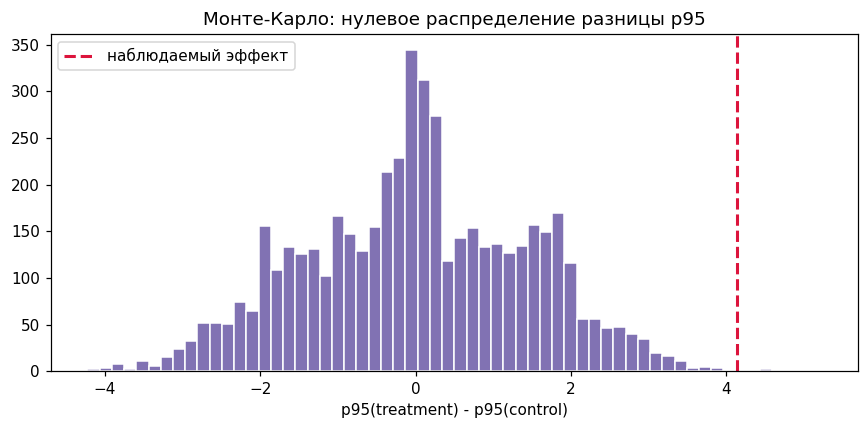

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(perm_diff, bins=60, color='#8172B3', edgecolor='white')
plt.axvline(obs_diff_p95, color='crimson', ls='--', lw=2, label='наблюдаемый эффект')
plt.title('Монте-Карло: нулевое распределение разницы p95')
plt.xlabel('p95(treatment) - p95(control)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Выводы

In [20]:
reject, p_adj, _, _ = multipletests([p_value, p_perm], alpha=0.05, method='holm')

pd.DataFrame({
    'metric': ['mean', 'p95'],
    'control': [mean_c, obs_p95_c],
    'treatment': [mean_t, obs_p95_t],
    'rel_lift': [rel_lift, obs_diff_p95 / obs_p95_c],
    'p_value': [p_value, p_perm],
    'p_value_holm': p_adj,
    'significant': reject,
})

,metric,control,treatment,rel_lift,p_value,p_value_holm,significant
0,mean,18.4520,19.1668,0.0387,0.0005,0.0011,True
1,p95,47.3340,51.4664,0.0873,0.0018,0.0018,True


**Итог.**

- Новый алгоритм ценообразования даёт статистически значимый прирост средней выручки с поездки (~4%), что превышает заложенный MDE 3%. Эффект на среднее подтверждён t-тестом Уэлча и бутстрэпом и сохраняется после поправки Холма. Ранговый критерий Манна-Уитни незначим (p ~ 0.18), так как эффект лежит в хвосте, а не в центре распределения.
- Монте-Карло по 95-му перцентилю выявил эффект в правом хвосте (~8.7%), заметно более сильный, чем сдвиг среднего: алгоритм сильнее всего повышает чек на дорогих поездках. Эффект не покрывается нулевым перестановочным распределением.
- **Решение:** раскатывать новый алгоритм. Прирост обеспечен в основном дорогими поездками, поэтому при мониторинге после раскатки стоит контролировать хвостовые метрики (p95/p99), а не только среднее.